# Algoritmos Genéticos

##Introdução

Os algoritmos genéticos são uma técnica de busca inspirada na evolução biológica. Eles são usados para resolver problemas de otimização e busca, onde a solução ideal é desconhecida ou difícil de encontrar.

Os algoritmos genéticos funcionam simulando a evolução de uma população de indivíduos, onde cada indivíduo representa uma solução potencial para o problema.

Os indivíduos são avaliados com base em sua aptidão (fitness), que é uma medida de quão bem eles resolvem o problema. Os indivíduos mais aptos são então selecionados para reprodução, e seus genes são combinados para criar uma nova geração de indivíduos.

Esse processo é repetido por várias gerações, até que uma solução ideal seja encontrada ou um critério de parada seja atingido.


A seguir é apresentada uma solução simples para exemplificar o uso de Algoritmos Genéticos.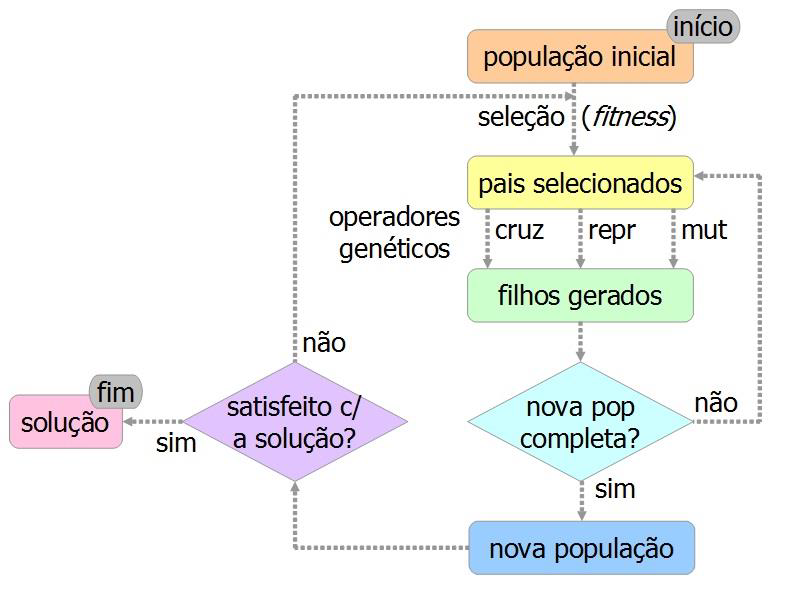

# Implementação

O Objetivo deste AG é encontrar uma "palavra secreta"

In [1]:
#instalação das bibliotecas para calculo do fitness
!pip install fuzzywuzzy
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.5 MB/s eta 0:00:00


In [20]:
import string
import random
from fuzzywuzzy import fuzz
from Levenshtein import distance as lev

Variáveis globais para execução

In [7]:
populacao = 100
geracoes = 100
in_str = "EngenhariaDeSoftware"
in_str_len = 20

Classe que define um indivíduo.

Cada indivíduo tem uma string (que é uma sequência aleatória de letras) e um valor de fitness, que é inicialmente definido como -1

In [26]:
class Individuo:
	def __init__(self,length):
		self.string = ''.join(random.choice(string.ascii_letters) for _ in range(length))
		self.fitness = 100000

A função `init_agentes` é usada para inicializar a população de indivíduos. Ela retorna uma lista de indivíduos, cada um com uma string aleatória de um determinado comprimento.

In [21]:
pop = [Individuo(in_str_len) for _ in range(10)]

for i in range(10):
  print(f"item : {pop[i].string} - Fitness: {lev(pop[i].string, in_str)}")

item : fgIOJhnAHuWqoGjWhoKe - Fitness: 18
item : WogoOvglTOUWRXxKbhKj - Fitness: 19
item : KuzdZNJoyAQiVoUVHzRY - Fitness: 19
item : YokgOlJGgjkGNaoZHlqY - Fitness: 19
item : AlcoIahgBuGpXaaYuxLz - Fitness: 20
item : NTMfOiknczHRQByouoey - Fitness: 20
item : eGRPtNAZCziYgmpffBGl - Fitness: 20
item : oGMrhSxYjFFPiCrgYaRr - Fitness: 19
item : RBqGTePETXEGBBbxxUck - Fitness: 20
item : SGZdAiFdXtJDQEMsMGub - Fitness: 20


In [10]:
def init_agentes(populacao,length):
	return [Individuo(length) for _ in range(populacao)]

A função `fitness` calcula o fitness de cada indivíduo na população. O fitness é calculado como a semelhança entre a string do indivíduo e uma string de entrada (`in_str`).

In [22]:
def fitness(individuos):
	for individuo in individuos:
		individuo.fitness = lev(individuo.string, in_str)
		# individuo.fitness = fuzz.ratio(individuo.string, in_str)
	return individuos

A função `selecao` seleciona a metade superior da população com base em seu fitness. Isso é feito ordenando a população em ordem decrescente de fitness e selecionando a primeira metade.

In [23]:
def selecao(individuos):
	individuos = sorted(individuos, key=lambda individuo: individuo.fitness)
 	# individuos = sorted(individuos, key=lambda individuo: individuo.fitness, reverse=True)
	individuos = individuos[:int(0.5*len(individuos))]
	return individuos

A função `crossover` realiza o crossover entre dois indivíduos para criar dois novos indivíduos. Isso é feito selecionando dois pais aleatoriamente, criando dois novos indivíduos e, em seguida, dividindo a string dos pais em um ponto de corte aleatório e trocando as partes para criar as strings dos filhos.

In [13]:
def crossover(individuos):
	filhos = []
	for _ in range(int(populacao/2)):
		pai1 = random.choice(individuos)
		pai2 = random.choice(individuos)
		filho1 = Individuo(in_str_len)
		filho2 = Individuo(in_str_len)
		corte = random.randint(0,in_str_len)
		filho1.string = pai1.string[0:corte]+pai2.string[corte:in_str_len]
		filho2.string = pai2.string[0:corte]+pai1.string[corte:in_str_len]
		filhos.append(filho1)
		filhos.append(filho2)
	individuos.extend(filhos)
	return individuos

A função `mutacao` realiza uma mutação em cada indivíduo com uma probabilidade de 5%. Se a mutação ocorrer, uma letra aleatória na string do indivíduo é alterada para outra letra aleatória.

In [49]:
def mutacao(individuos):
    for individuo in individuos:
        for idx, param in enumerate(individuo.string):
            if random.uniform(0.0, 1.0) <= 0.001:
                individuo.string = individuo.string[0:idx] + random.choice(string.ascii_letters) + individuo.string[idx+1:in_str_len]
    return individuos

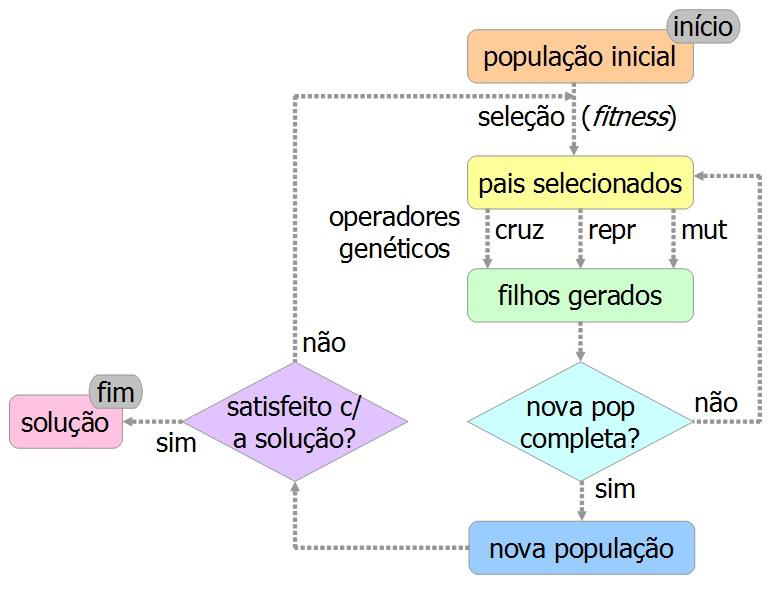

Finalmente, a função ga implementa o pipeline de um algoritmo genético.



In [30]:
def ga():

	individuos = init_agentes(populacao, in_str_len)

	max_fitness_por_geracao = []

	for geracao in range(geracoes):

		# print('Generation: ' + str(geracao))

		individuos = fitness(individuos)

		individuos = selecao(individuos)

		individuos = crossover(individuos)

		individuos = mutacao(individuos)

		# best = sorted(individuos, key=lambda individuo: individuo.fitness, reverse=True)[0]
		best = sorted(individuos, key=lambda individuo: individuo.fitness)[0]

		max_fitness_por_geracao.append(best.fitness)

		if geracao % 10 == 0:
			print(f"{geracao} - indivíduo: {best.string} - fitness: {best.fitness}")

		if best.fitness == 100:
			break

	return max_fitness_por_geracao

se o script for executado como o principal, ele define a string de entrada, calcula seu comprimento e chama a função ga para iniciar o algoritmo genético.

In [50]:
geracoes = 2000
in_str = "SistemasInteligentesAplicadosSistemasInteligentesAplicadosSistemasInteligentesAplicados"
in_str_len = len(in_str)

evolution = ga()



0 - indivíduo: hgZeHrYXObvJezLoIJZTkLfcZGeIFSODGobXgnIqKbVoGtLjiYxyNOVWRMGlbavMpNLbeyJfGICXpxpwDXVKdDe - fitness: 81
10 - indivíduo: yiMnAVVZQCtTHyAnqJepApjSmByobsMKrynUotQHJdgBBEvEpbDRLdnzJcsdmjivMnSItDQnNolTeAoaAhiclos - fitness: 72
20 - indivíduo: yiMnYmsFnQlBHGCtsJttmKyAoSAysYxwSAsIotYMCneqmEvEpbNRLdnzJcsdmjivMnSItDQnNolTeAoWlhicWos - fitness: 67
30 - indivíduo: yiMnYmsFnptNDqmBLGepApjSmByoisMKpAsIotQHJdgBnEvEpbDRLdnzJcsdmjivMnSItDQnNolTeAoWlhicWos - fitness: 65
40 - indivíduo: yiMnYmsFnQtNHGCtsJepApjSmByoisMKpAsIotQHJdgBnWBrkpfiLdnzJcsdmjivInSItDQnNolTeAoWlhicWos - fitness: 63
50 - indivíduo: yiMnemsFnQtNHqmeLGepApjSmByoisMKpAsIotQHJdgBnWBrkpfiLdnzJcsdmjivInSItDQnNolTeAoWlhicWos - fitness: 61
60 - indivíduo: yisnemsFnQtNHqmeLGepApjSmByoisMKpAsIotQHJdgBnWBrkpfiLdnzJcsdmjivInSItDQnjolTeAoWlhiclos - fitness: 60
70 - indivíduo: yisnemsFnQtNHqmenGepApjSmByoisMKpAsIotQHJdgBnWBrkpfiLdnzJLsnZQemoUbItDQnNolTeeoPlhicHos - fitness: 59
80 - indivíduo: yisnemsFnQtNHqmenGepApjSmByoisMKpAsIotQHJ

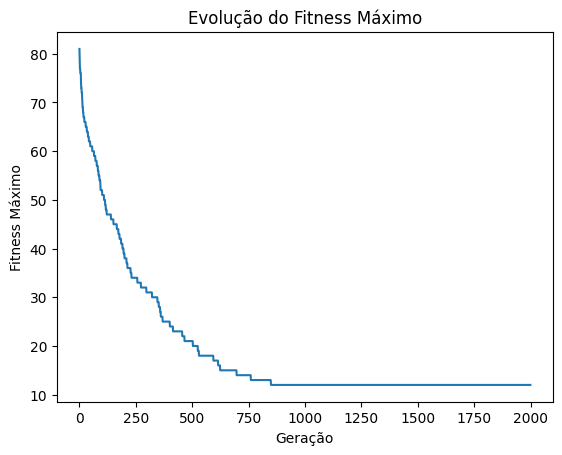

In [51]:
import matplotlib.pyplot as plt

def plot_fitness(max_fitness_por_geracao):
  plt.plot(max_fitness_por_geracao)
  plt.title('Evolução do Fitness Máximo')
  plt.xlabel('Geração')
  plt.ylabel('Fitness Máximo')
  plt.show()

plot_fitness(evolution)